## Preparation

In [1]:
import torch
import torchvision
from pathlib import Path
from models_arch.Recognizer import *
from utils.randimage import RandomLinesGenerator
import matplotlib.pyplot as plt
import numpy as np
import os

In [2]:
model = RecognizerOneConv()
model.load()

class_mapper: dict = {
    0: '0',
    1: '1',
    2: '2',
    3: '3',
    4: '4',
    5: '5',
    6: '6',
    7: '7',
    8: '8',
    9: '9',
    10: 'blank',
}

## Visualize the kernels

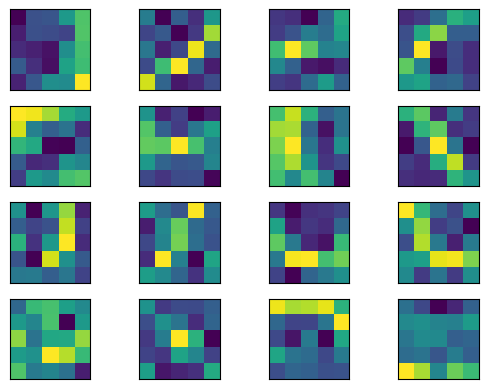

In [3]:
fig, axes = plt.subplots(4, 4, sharex=True, sharey=True, subplot_kw={'xticklabels': '', 'yticklabels': '', 'xticks': (50,), 'yticks': (50,)})
with torch.no_grad():
    for idx, ker in enumerate(model.kernels):


        axes[idx // 4, idx % 4].imshow(1 - ker.squeeze(0))


In [4]:
device = torch.accelerator.current_accelerator(check_available=True)
if device is None:
    device = torch.device('cpu')

print(f"Chosen device: {device}{':'+device.index if device.index is not None else ''}")

# CUDA Optimizations
if device.type == 'cuda':
    torch.backends.cudnn.benchmark = True  # Auto-tune convolution algorithms
    torch.backends.cudnn.enabled = True
    print("CUDNN optimizations enabled")
else:
    print("Running on CPU - CUDA optimizations disabled")

MNIST_PATH = Path("datasets/MNIST")
BLANK_DATASET_PATH = Path("datasets/Blanks")
BLANKS_PATH = BLANK_DATASET_PATH / 'blank'

os.makedirs(MNIST_PATH, exist_ok=True)

for i in range(0, 10):
    os.makedirs(BLANK_DATASET_PATH / str(i), exist_ok=True)

os.makedirs(BLANKS_PATH, exist_ok=True)

# uncomment following lines for generation of blank dataset

# blanks_generator = RandomLinesGenerator() # calling this generates an image
# # we want to generate around 8000 images in order to have balanced dataset
# # training <- 7000
# # testing <- 1000
# for i in range(8000): 
#     torchvision.utils.save_image(blanks_generator(), BLANKS_PATH / f"img{i}.png")
# Data Augmentation - Apply RandomRotation, RandomAffine and ElasticTransform to train dataset
train_transform = torchvision.transforms.Compose([
    torchvision.transforms.RandomAffine(degrees=15, translate=(0.1, 0.1), scale=(0.85, 1.15)),
    torchvision.transforms.Grayscale(num_output_channels=1),
    torchvision.transforms.ToTensor()
])

# Preserve test dataset clean without any transform effects applied
test_transform = torchvision.transforms.Compose([
    torchvision.transforms.Grayscale(num_output_channels=1),
    torchvision.transforms.ToTensor()
])
blank_dataset = torchvision.datasets.ImageFolder(
    BLANK_DATASET_PATH,
    allow_empty=True,
    transform=train_transform
)

generator = torch.Generator()

blank_train, blank_test = torch.utils.data.random_split(blank_dataset, [7/8, 1/8])

train_MNIST = torchvision.datasets.MNIST(
    MNIST_PATH, train=True, transform=train_transform, download=True
)

test_MNIST = torchvision.datasets.MNIST(
    MNIST_PATH, train=False, transform=test_transform, download=True
)

full_train_dataset = torch.utils.data.ConcatDataset([train_MNIST, blank_train])
full_test_dataset =  torch.utils.data.ConcatDataset([test_MNIST, blank_test])

# Split train dataset into train subset and validation subset
train_subset, val_subset = torch.utils.data.random_split(
    full_train_dataset, [0.8, 0.2], generator=generator
)


Chosen device: cuda
CUDNN optimizations enabled


## Visualize each kernel's predictions

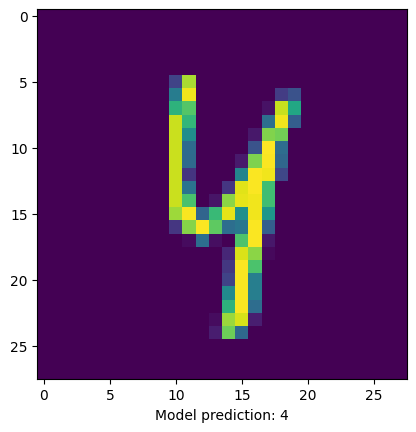

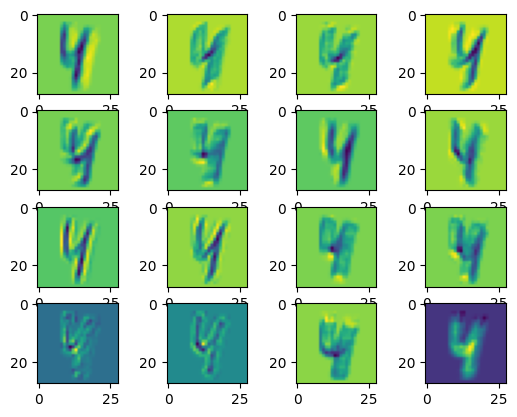

In [18]:
im: torch.Tensor = full_test_dataset[np.random.randint(0, len(full_test_dataset))][0].squeeze()
with torch.no_grad():
    plt.imshow(im)
    plt.xlabel(f'Model prediction: {torch.argmax(model(im.unsqueeze(0).unsqueeze(0)))}')
    plt.show()
    
    fig, axes = plt.subplots(4,4)
    for idx, k in enumerate(model.kernel_preds(im)):
        axes[idx // 4, idx % 4].imshow(k)